### Notebook para evaluar la separación de imagenes de distitnos modelos


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import sys


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from project.loader import load
from project.CROP.models.crop2 import Crop2 
from project.custom_layers.reshapeLayer import ReshapeLayer
from keras.models import load_model

SEED = 1234
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


dataset = "fashion"

cvae = load.cvae(inter=20,lat=128,dataset=dataset)
data = load.data(dataset=dataset)

predictor = load.predictor(dataset=dataset)


x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


c = Crop2(cvae=cvae,predictor=predictor)
n_images=10

labels=["0","1","2","3","4","5","6","7","8","9","0"]
labels = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

params_acc_both_mnist = {'gamma': 0.3012911033494221} # optimización de acc
recon_bpsnr_params_fashion={'bias': 0.1943216020281843, 'slope': 13.31893832689755, 'alpha_1': -4.404314358094745, 'alpha_2': -18.09515909301692, 'gamma': 0.9988131660741272}

metrics = c.unmix(
    x_test[:n_images],
    x_test_1[:n_images],
    y_test[:n_images],
    y_test_1[:n_images],
    params=recon_bpsnr_params_fashion,
    iterations=10,
    show_image=True
)



: 

2025-12-21 01:35:50.515035: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-21 01:35:50.515446: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-21 01:35:50.518584: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-21 01:35:50.526519: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766291750.538257  589367 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766291750.54

Usando mnist como dataset


2025-12-21 01:35:52.477029: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-12-21 01:35:54.425961: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


430/430 ━━━━━━━━━━━━━━━━━━━━ 80s 182ms/step - loss: 0.0772 - val_loss: 0.0606


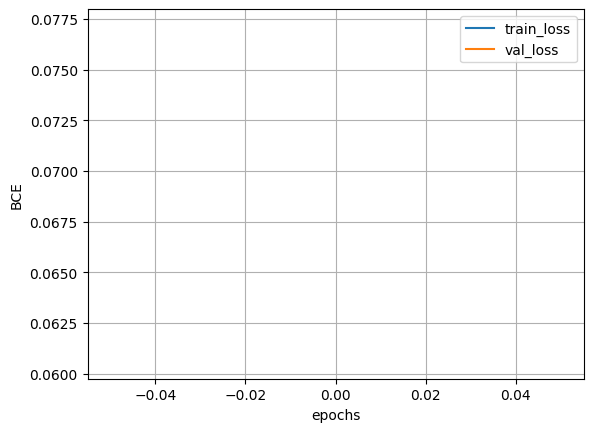


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -2.000
alpha_2   : -22.000
bias      : 0.220
slope     : 22.000
gamma     : 0.330
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 11.247  std:1.192
mask_bpsnr       : mean: 9.987  std:1.157
ssim             : mean: 0.443  std:0.031
acc_at_least_one : 0.700
acc_both         : 0.200



KeyError: 'bpsnr'

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from project.models_definitions.unet import build_conditional_unet_mnist
from project.loader import load
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from project.CROP.models.crop2_unet import Crop2Unet

dataset = "mnist"

data = load.data(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


x_train = data["x_train"]
y_train = data["y_train"]

x_val = data["x_val"]
y_val = data["y_val"]



x_train = np.array(x_train)
x_val   = np.array(x_val)
x_test   = np.array(x_test)
x_test_1 =  np.array(x_test_1)

x_train = x_train.reshape(-1, 28, 28, 1)
x_val   = x_val.reshape(-1, 28, 28, 1)

model = build_conditional_unet_mnist()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy"
)

optimizer = tf.keras.optimizers.Adam()
model.compile(optimizer=optimizer)

history = model.fit(
    [x_train, y_train],
    x_train,
    batch_size=128,
    epochs=1,
    validation_data=([x_val, y_val], x_val)
)


plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epochs")
plt.ylabel("BCE")
plt.grid()
plt.legend()
plt.show()


predictor = load.predictor(dataset=dataset)


c = Crop2Unet(model,predictor=predictor)

start =0
end =start+10

metrics  = c.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=3,
    show_image=False)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])


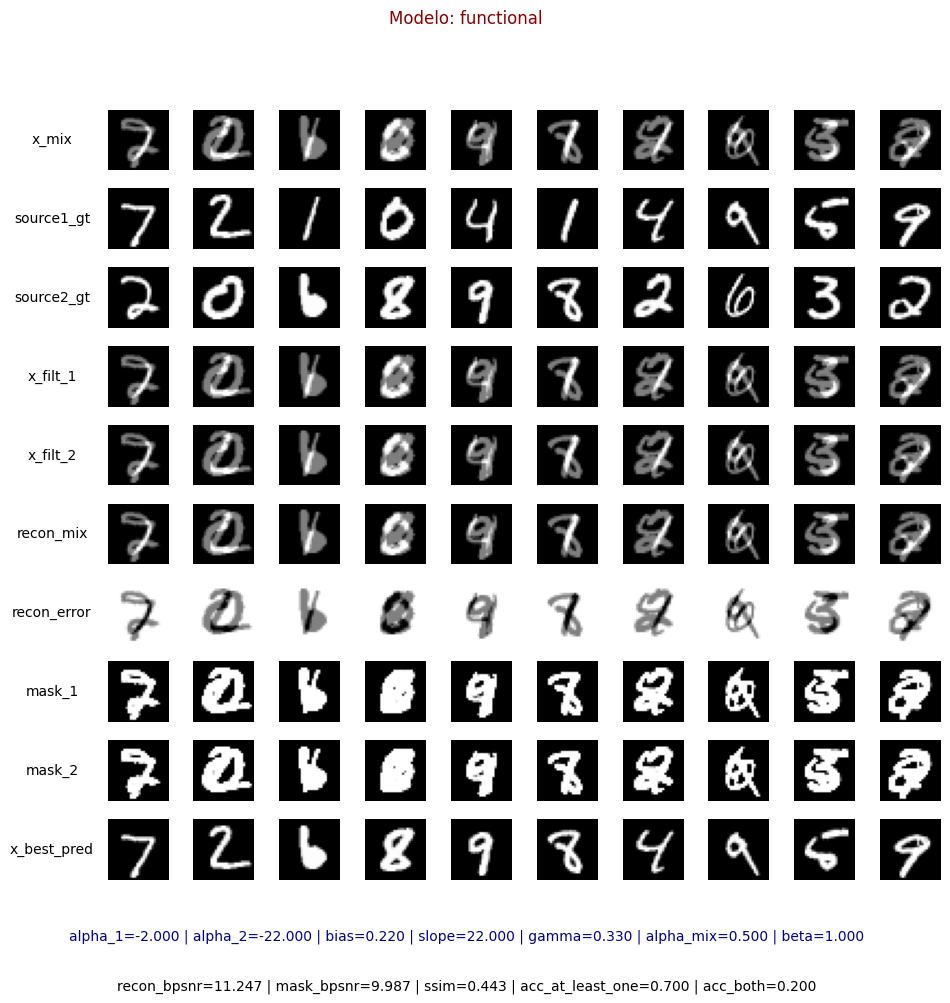


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -2.000
alpha_2   : -22.000
bias      : 0.220
slope     : 22.000
gamma     : 0.330
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 11.247  std:1.192
mask_bpsnr       : mean: 9.987  std:1.156
ssim             : mean: 0.443  std:0.031
acc_at_least_one : 0.700
acc_both         : 0.200



KeyError: 'bpsnr'

In [ ]:

metrics  = c.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True)




-------------------------------------------------------------------------------------------------------------------------


In [2]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop import crop

dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=64, inter=128,dataset=dataset)


# bias default: 0.22
# slope default: 22

# bias optimizados: 0.18495822150909808,
# slope optimizados: 18.248678323921897

crop_f0 = crop(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope=18.248678323921897 ,beta=1)

start =0
end =start+10

metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    show_image=True)


ImportError: cannot import name 'load' from 'experiments' (/home/galsan/Desktop/tesis/CROP_1/project/experiments/__init__.py)

In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop import crop

dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=256, inter=512,dataset=dataset)


#crop_f0 = crop(model,predictor=predictor,data=data)

# crop_f0 = crop(model,predictor=predictor,
#                data=data,bias=0.2562,slope=10.0067 ,beta=1)


crop_f0 = crop(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope= 18.248678323921897,beta=1)

start =0
end =start+1000


metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])


Usando fashion como dataset
(<tf.Tensor: shape=(), dtype=float32, numpy=17.786474227905273>, <tf.Tensor: shape=(), dtype=float32, numpy=2.863659381866455>)
0.9554
0.5416


# Rsumen de estadisticas:(usando 1000 imagenes y 3 iteraciones)

## Antes de los cambios: 
#### Parametros: bias: 0.22 slope: 22
 - Bpsnr:  bpsnr_mean:  14.927 bpsnr_std: 2.45 

 - Acc:  Acc_at_least_one: 0.969  Acc_both: 0.564
 
 ## Despues de los cambios: 
#### Parametros: bias: 0.22 slope: 22
 - Bpsnr:  bpsnr_mean:  17.96  bpsnr_std: 3.50

 - Acc:  Acc_at_least_one: 0.966  Acc_both: 0.617
 
## Despues de los cambios y parametros optimizados: 
#### Parametros: bias=0.18495822150909808  slope= 18.248678323921897
 - Bpsnr:  bpsnr_mean:  18.39  bpsnr_std: 3.05

 - Acc:  Acc_at_least_one: 0.967  Acc_both: 0.653
 
guardar el resutaldo parcial del acc, ver evolucion pasos acc. (usando dataset de testeo) 

Usando fashion como dataset


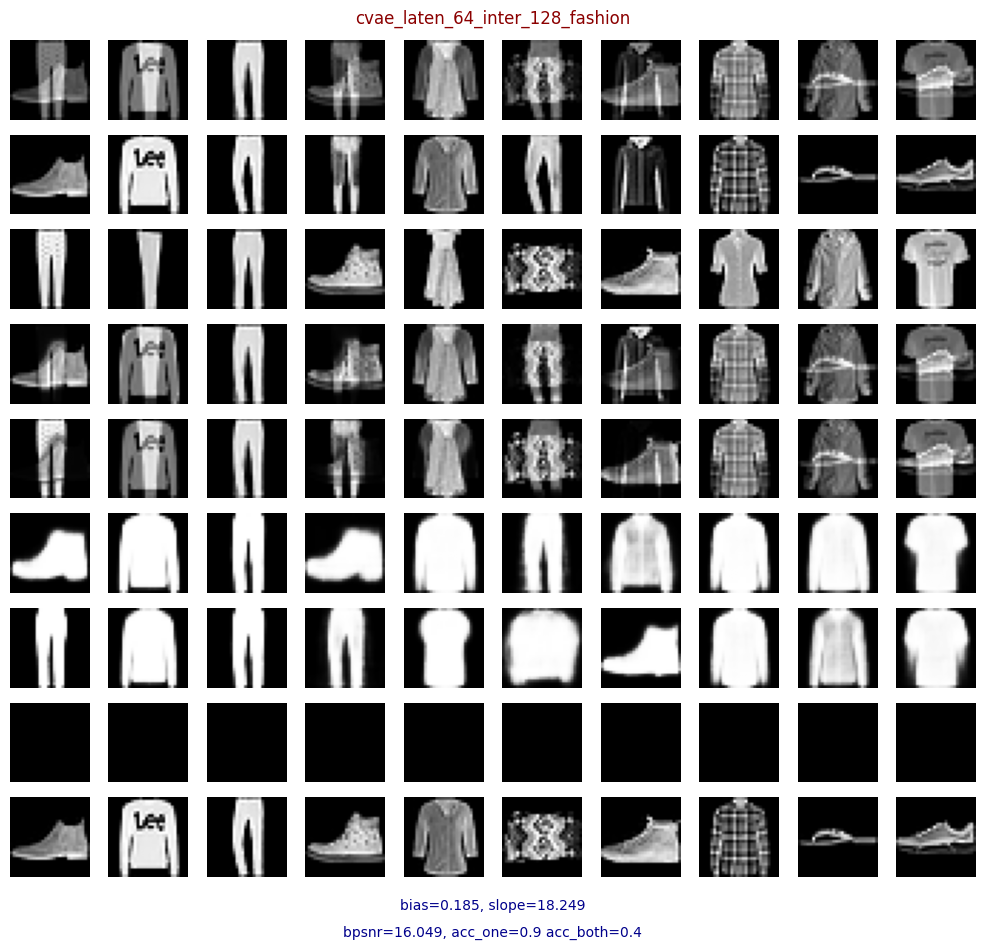

(<tf.Tensor: shape=(), dtype=float32, numpy=16.049243927001953>, <tf.Tensor: shape=(), dtype=float32, numpy=3.037189483642578>)
0.9
0.4


In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop import crop

dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=64, inter=128,dataset=dataset)

#crop_f0 = crop(model,predictor=predictor,
#               data=data,bias=0.2562,slope=10.0067 ,beta=1)


crop_f0 = crop(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope= 18.248678323921897,beta=1)

start =0
end =start+10


metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    show_image=True)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])


In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load


dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=64, inter=128,dataset=dataset)

#crop_f0 = crop(model,predictor=predictor,
#               data=data,bias=0.2562,slope=10.0067 ,beta=1)


crop_f0 = crop(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope= 18.248678323921897,beta=1)

start =0
end =start+10


metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    Iterations=100,
    show_image=True)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

Usando fashion como dataset


TypeError: crop.unmix() got an unexpected keyword argument 'Iterations'

2025-10-27 17:07:13.832665: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 17:07:13.836083: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 17:07:13.845901: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761595633.862890 1771050 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761595633.867943 1771050 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761595633.896508 1771050 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Usando fashion como dataset


2025-10-27 17:07:16.562611: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-10-27 17:07:16.562629: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-10-27 17:07:16.562634: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: pc-santi
2025-10-27 17:07:16.562638: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: pc-santi
2025-10-27 17:07:16.562694: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 575.64.3
2025-10-27 17:07:16.562712: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:201] kernel reported version is: 575.64.3
2025-

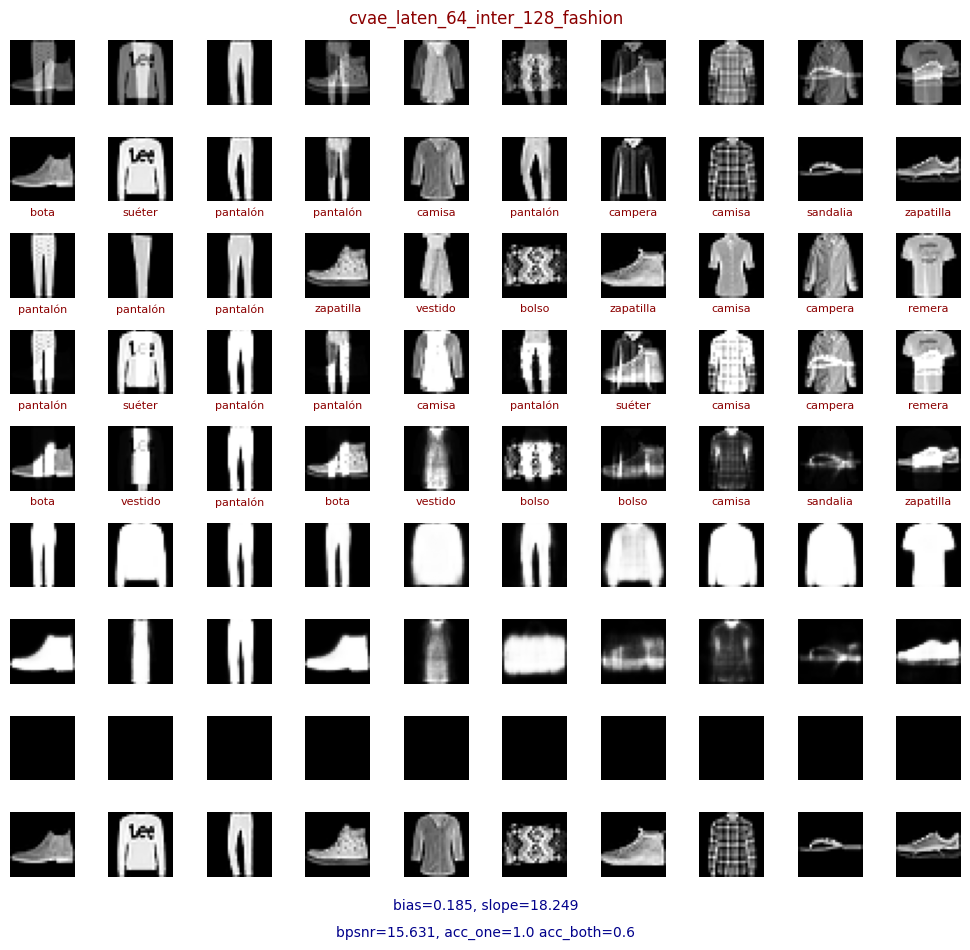

(<tf.Tensor: shape=(), dtype=float32, numpy=15.631418228149414>, <tf.Tensor: shape=(), dtype=float32, numpy=2.4072885513305664>)
1.0
0.6


In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop1_model import Crop1

dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=64, inter=128,dataset=dataset)

#crop_f0 = crop(model,predictor=predictor,
#               data=data,bias=0.2562,slope=10.0067 ,beta=1)


crop_f0 = Crop1(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope= 18.248678323921897,beta=1)

start =0
end =start+10


metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

Usando fashion como dataset


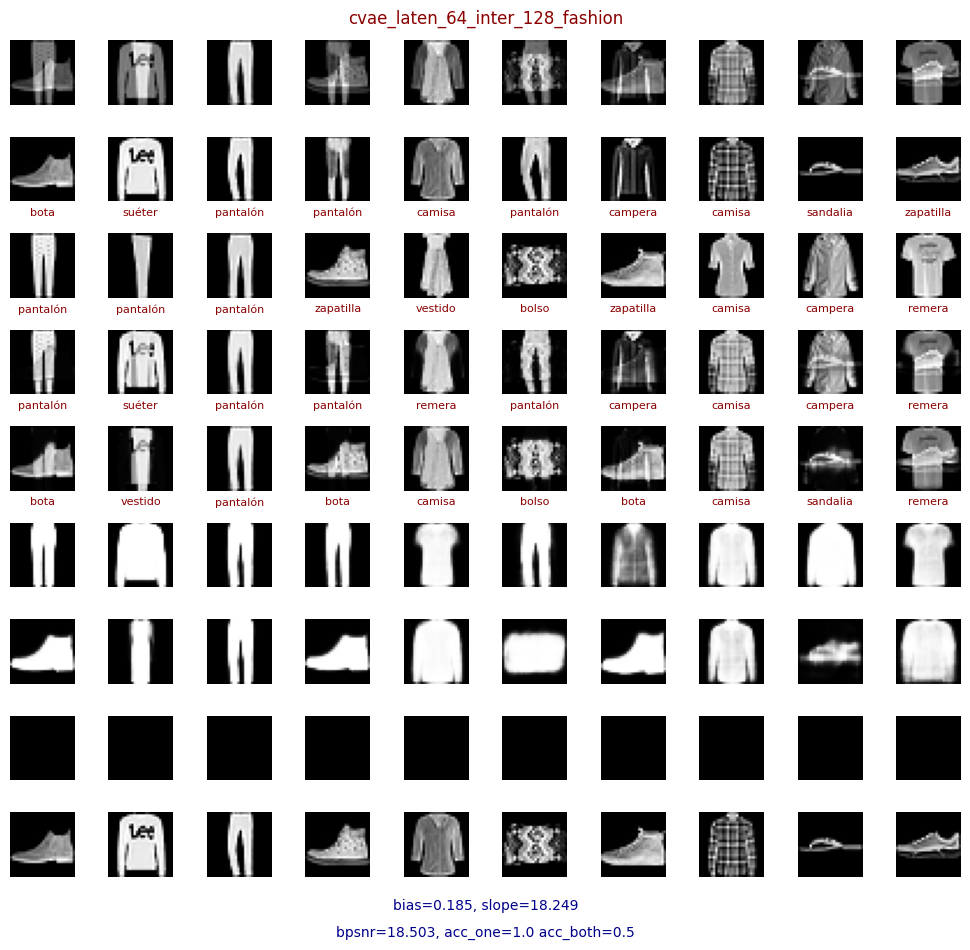

(<tf.Tensor: shape=(), dtype=float32, numpy=18.503110885620117>, <tf.Tensor: shape=(), dtype=float32, numpy=3.1964430809020996>)
1.0
0.5


In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop2_model import Crop2

dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=64, inter=128,dataset=dataset)

#crop_f0 = crop(model,predictor=predictor,
#               data=data,bias=0.2562,slope=10.0067 ,beta=1)


crop_f0 = Crop2(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope= 18.248678323921897,beta=1,gamma=1)

start =0
end =start+10

metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

# anotar clases de las imagenes reconstruidas...
#idea
#revisar acc uno y acc ambos

Usando fashion como dataset


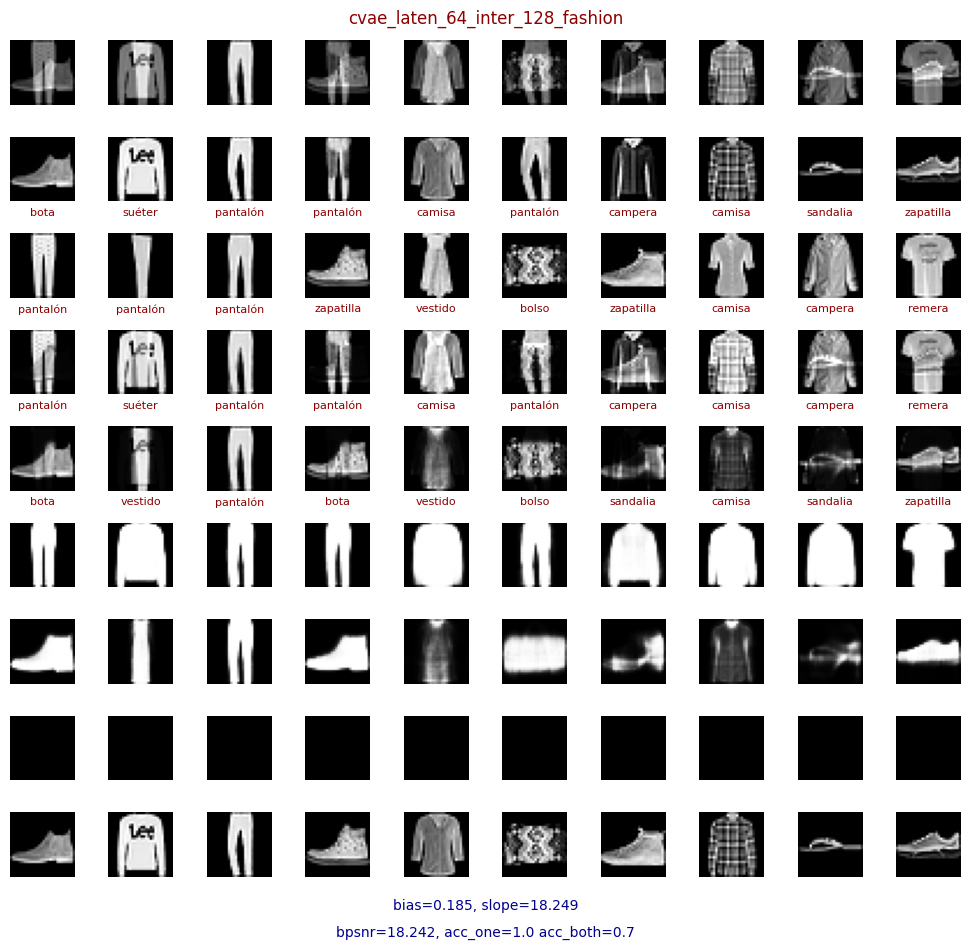

(<tf.Tensor: shape=(), dtype=float32, numpy=18.241710662841797>, <tf.Tensor: shape=(), dtype=float32, numpy=3.9651787281036377>)
1.0
0.7


In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop2_norm import Crop2

dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=64, inter=128,dataset=dataset)

#crop_f0 = crop(model,predictor=predictor,
#               data=data,bias=0.2562,slope=10.0067 ,beta=1)


crop_f0 = Crop2(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope= 18.248678323921897,beta=1)

start =0
end =start+10


metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=10,
    show_image=True)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

Comparación entre normalizaciones

Normalización entre reconstrucciones (3 iteraciones )

In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop2_norm import Crop2

dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=64, inter=128,dataset=dataset)


crop_f0 = Crop2(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope= 18.248678323921897,beta=1)

start =0
end =start+1000


metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=3,
    show_image=False)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])

2025-10-15 19:12:29.443609: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-15 19:12:29.447921: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-15 19:12:29.458679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760566349.479935   14417 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760566349.485904   14417 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760566349.499428   14417 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Usando fashion como dataset


E0000 00:00:1760566352.146400   14417 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1760566352.146960   14417 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


(<tf.Tensor: shape=(), dtype=float32, numpy=18.113405227661133>, <tf.Tensor: shape=(), dtype=float32, numpy=3.0413763523101807>)
0.969
0.641



Solo gamma 2
bpsnr= 16.266643524169922 std= 2.4388673305511475
acc uno = 0.965
acc ambos = 0.602



----------------

Normalizacion al final
bpsnr= 18.113405227661133 std= 3.04137
acc uno = 0.969
acc ambos = 0.641

---------------


Normalizacion al final más gamma

bpsnr = 18.198944091796875  std  = 2.917802333831787
acc uno = 0.968
acc ambos = 0.64
----------------


In [ ]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop2_gamma_norm import Crop2

dataset="fashion"

data = load.data(dataset=dataset)
predictor = load.predictor(dataset=dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  
x_test_1  =data["x_test_1"]
y_test_1  =data["y_test_1"]


model = load.cvae(lat=2, inter=128,dataset=dataset)


crop_f0 = Crop2(model,predictor=predictor,
               data=data,bias=0.18495822150909808,slope= 18.248678323921897,beta=1)

### optimizados para acc_both {'bias': 0.2779424046498654, 'slope': 13.922830720253256}

crop_f0 = Crop2(model,predictor=predictor,
               data=data,bias=0.16714821597235163,slope= 17.655762570892875,beta=1)
start =0
end =start+1000


metrics  = crop_f0.unmix(
    x_test[start:end],
    x_test_1[start:end],
    y_test[start:end],
    y_test_1[start:end],
    iterations=3,
    show_image=False)


print(metrics["bpsnr"])
print(metrics["acc_at_least_one"])
print(metrics["acc_both"])


Usando fashion como dataset
(<tf.Tensor: shape=(), dtype=float32, numpy=17.831871032714844>, <tf.Tensor: shape=(), dtype=float32, numpy=2.6109867095947266>)
0.959
0.617


Unet